In [1]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime torch torchvision

Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.amazonaws.com


In [2]:
import numpy as np
from qiskit import QuantumCircuit, Aer, assemble
from qiskit.circuit import Parameter

class MyQuantumCircuit:
    def __init__(self, n_qubits, backend, shots):
        self._circuit = QuantumCircuit(n_qubits)
        all_qubits = [i for i in range(n_qubits)]

        self.theta_params = [Parameter(f'theta{i}') for i in range(7)]

        self._circuit.h(all_qubits)
        self._circuit.barrier()
        self._circuit.ry(self.theta_params[0], all_qubits)
        self._circuit.cz(0,1)
        self._circuit.cz(1,2)
        self._circuit.ry(self.theta_params[1], 0)
        self._circuit.ry(self.theta_params[2], 1)
        self._circuit.ry(self.theta_params[3], 2)
        self._circuit.cz(0,1)
        self._circuit.cz(1,2)
        self._circuit.ry(self.theta_params[4], 0)
        self._circuit.ry(self.theta_params[5], 1)
        self._circuit.ry(self.theta_params[6], 2)
        self._circuit.measure_all()

        self.backend = backend
        self.shots = shots

    def run(self, thetas):
        parameter_binds = {param: value for param, value in zip(self.theta_params, thetas)}

        bound_circuit = self._circuit.bind_parameters(parameter_binds)

        qobj = assemble(bound_circuit,
                        shots=(self.shots))

        job = self.backend.run(qobj)
        result = job.result()

        counts = result.get_counts(bound_circuit)

        expects = np.zeros(8)
        for k, key in enumerate(['000', '001', '010', '011', '100', '101', '110', '111']):
            perc = counts.get(key, 0) / self.shots
            expects[k] = perc
        return expects

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel="ibm_cloud", token="8xwyk4bF8_xCYIq1QIMjMd2dzFfx0DDLSiPcuzSKgimt", instance="crn:v1:bluemix:public:quantum-computing:us-east:a/4eac2ac68c7b4e0689e4945264aafbfb:72cb1f90-81af-421e-8da8-1216f9040eb8::")
#QiskitRuntimeService.save_account(channel="ibm_cloud", token="8xwyk4bF8_xCYIq1QIMjMd2dzFfx0DDLSiPcuzSKgimt", instance="crn:v1:bluemix:public:quantum-computing:us-east:a/4eac2ac68c7b4e0689e4945264aafbfb:72cb1f90-81af-421e-8da8-1216f9040eb8::")
service = QiskitRuntimeService()

In [5]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import QiskitRuntimeService, Estimator, Session, Options

# Initialize the Qiskit Runtime service
service = QiskitRuntimeService()
options = Options() 
options.optimization_level = 2 
options.resilience_level = 0 

# Create a QuantumCircuit instance
backend = service.get_backend("ibmq_qasm_simulator")
circuit = MyQuantumCircuit(3, backend, 100000)._circuit  # Use ._circuit to get the QuantumCircuit instance

# Define set of parameters for the circuit
parameter_values = [1, 2, 1, 4, 5, 6, 8]
observables = SparsePauliOp("ZIZ") 
with Session(service=service, backend=backend) as session: 
    estimator = Estimator(session=session, options=options) 
    job = estimator.run([circuit], [observables], parameter_values)  
    result = job.result() 

print(f">>> Expectation value: {result.values[0]}")
print(f">>> Metadata: {result.metadata[0]}")
print(circuit.draw())

>>> Expectation value: 0.597
>>> Metadata: {'variance': 0.643591, 'shots': 4000}
        ┌───┐ ░ ┌────────────┐   ┌────────────┐                 ┌────────────┐»
   q_0: ┤ H ├─░─┤ Ry(theta0) ├─■─┤ Ry(theta1) ├───────────────■─┤ Ry(theta4) ├»
        ├───┤ ░ ├────────────┤ │ └────────────┘┌────────────┐ │ └────────────┘»
   q_1: ┤ H ├─░─┤ Ry(theta0) ├─■───────■───────┤ Ry(theta2) ├─■───────■───────»
        ├───┤ ░ ├────────────┤         │       ├────────────┤         │       »
   q_2: ┤ H ├─░─┤ Ry(theta0) ├─────────■───────┤ Ry(theta3) ├─────────■───────»
        └───┘ ░ └────────────┘                 └────────────┘                 »
meas: 3/══════════════════════════════════════════════════════════════════════»
                                                                              »
«                       ░ ┌─┐      
«   q_0: ───────────────░─┤M├──────
«        ┌────────────┐ ░ └╥┘┌─┐   
«   q_1: ┤ Ry(theta5) ├─░──╫─┤M├───
«        ├────────────┤ ░  ║ └╥┘┌─┐
«   q_2: ┤ Ry(theta

In [6]:
import torch
from torch.autograd import Function
from torchvision import datasets, transforms
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

In [7]:
#This class defines what our hybrid layer does. It allows it to go forward, and also backprop
class HybridFunction(Function):

  @staticmethod
  def forward(ctx, input, quantum_circuit, shift):
    ctx.shift = shift
    ctx.quantum_circuit = quantum_circuit

    parameter = []

    #A very scrapy but functional way of loading the parameters in this format
    for x in input:
      for y in x:
        parameter.append(float(y))
    # print(parameter)

    #Aka we run the input into our circuit
    expectation_z = ctx.quantum_circuit.run(parameter) #Might need to change this when have multi-layer
    #Shoves to pytorch tesnor
    result = torch.tensor([expectation_z])
    #Save the input and result for backpropagation
    ctx.save_for_backward(input,result)
    #return output
    return result

  @staticmethod
  def backward(ctx, grad_output):
    #Regrabing the input and the output
    input, expectation_z = ctx.saved_tensors
    # input_list = np.array(input.tolist())
    # print(input)

    input_list = list(input)[0]
    # print(input_list)

    #A list of all the gradients
    gradients = torch.Tensor()

    #We're going to go through the inputs and then calculate the gradient for each one
    for i in range(7):
      #In order to get the gradients for each one, we shift one of the parameters a tiny bit and find the difference in the outputs... Since we can't do backprop on it, we use something called shift parameter
      shift_right = np.array(input_list.detach().clone())
      shift_left = np.array(input_list.detach().clone())
      shift_right[i] = shift_right[i] + ctx.shift
      shift_left[i] = shift_left[i] - ctx.shift

      #So we take the shifted ones and just compute it
      expectation_right = ctx.quantum_circuit.run(shift_right)
      expectation_left  = ctx.quantum_circuit.run(shift_left)
      #Gradient = appox the difference (division by 2*shift isn't necessary since it'll just be a scaled version (which can be counteracted by lr))
      gradient = torch.tensor([expectation_right]) - torch.tensor([expectation_left])
      #Append the gradient to the meta list
      gradients  = torch.cat((gradients, gradient.float()))

    #Format everything
    result = torch.Tensor(gradients)
    result = result.float()
    result = result.T

    #Just a random varaible that made my life easier when debugging
    Fixer = grad_output.float()
    Fixer = Fixer.T

    #Find the gradients at last!!!
    h = result * Fixer
    #then return it for backprop
    return h, None, None

In [8]:
#This defines the acutal thing that we're shoving into the NN
class Hybrid(nn.Module):
  #initialization
  def __init__(self, backend, shots, shift):
    super(Hybrid, self).__init__()
    #Define the real quantum circuit that we'll be using for our thing
    self.quantum_circuit = MyQuantumCircuit(3, backend, shots)
    #Save this guy for alter
    self.shift = shift

  #When forwarding
  def forward(self, input):
    return HybridFunction.apply(input, self.quantum_circuit, self.shift)

In [9]:
import boto3
import torchvision.transforms as transforms
import torch.utils.data
from torchvision import datasets

bucket = 'idrid-dataset'
prefix = 'gaussian_filtered_images'
data_location = f's3://{bucket}/{prefix}/'
# Initialize variables for pagination
files = []
continuation_token = None

# Create an S3 client
s3_client = boto3.client('s3')

# Loop to retrieve all object keys
while True:
    if continuation_token:
        response = s3_client.list_objects_v2(Bucket=bucket, Prefix=prefix, ContinuationToken=continuation_token)
    else:
        response = s3_client.list_objects_v2(Bucket=bucket, Prefix=prefix)

    # Add retrieved object keys to the files list
    files.extend([obj['Key'] for obj in response.get('Contents', [])])

    # Check if there are more objects to retrieve
    if 'NextContinuationToken' in response:
        continuation_token = response['NextContinuationToken']
    else:
        break

In [12]:
# Specify the subfolders within the prefix
subfolders = ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']

# Define new prefixes for train and test sets
train_prefix = 'train_data/'
test_prefix = 'test_data/'

# Loop through the subfolders and move/copy the data
for subfolder in subfolders:
    # List objects in the subfolder
    response = s3_client.list_objects_v2(Bucket=bucket, Prefix=f'{prefix}/{subfolder}/')
    objects = response.get('Contents', [])
    
    # Determine the split point for train and test data
    split_point = int(len(objects) * 0.8)  # 80% for training, 20% for testing
    
    # Move or copy the data to train and test folders
    for idx, obj in enumerate(objects):
        source_key = obj['Key']
        destination_prefix = train_prefix if idx < split_point else test_prefix
        destination_key = f'{destination_prefix}{subfolder}/{source_key.split("/")[-1]}'
        
        # Copy the object (you can use 'move_object' if you want to move)
        s3_client.copy_object(CopySource={'Bucket': bucket, 'Key': source_key},
                              Bucket=bucket, Key=destination_key)

/tmp/ipykernel_10779/3040164674.py:16: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


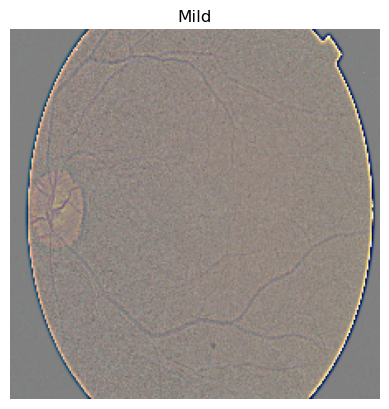

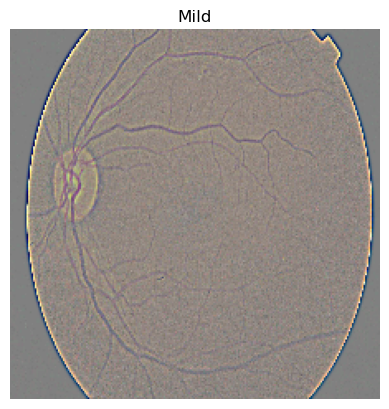

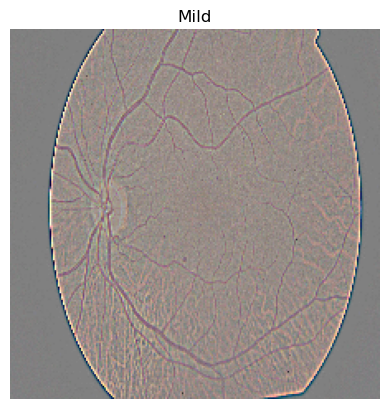

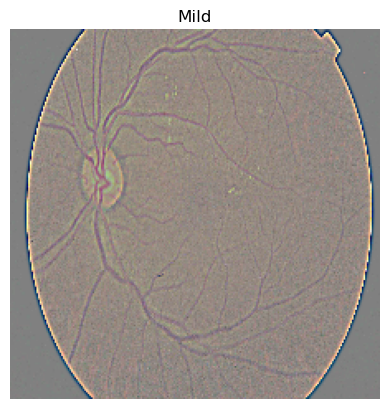

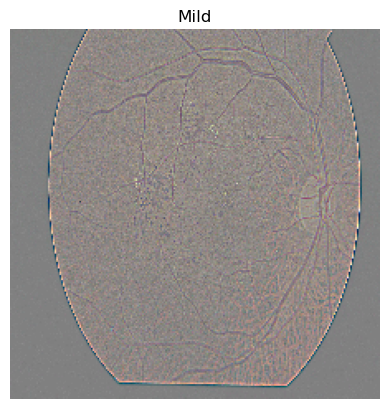

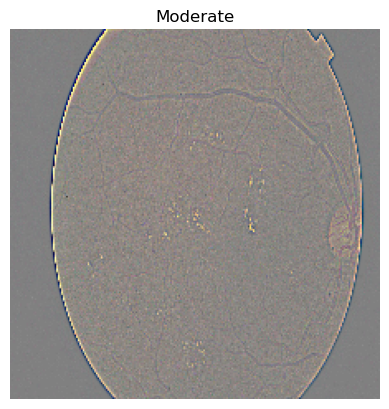

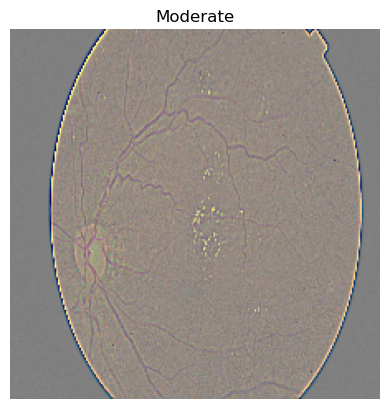

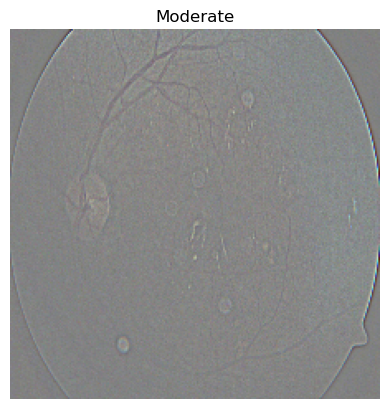

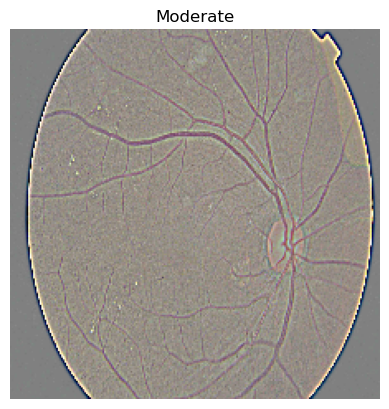

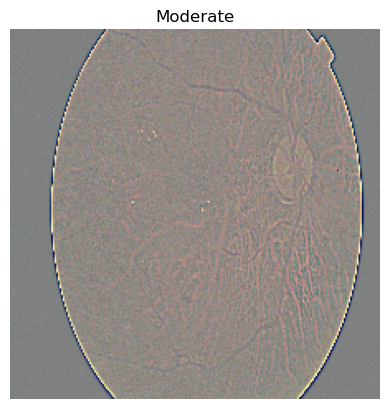

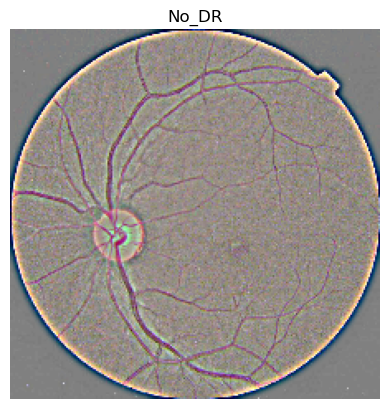

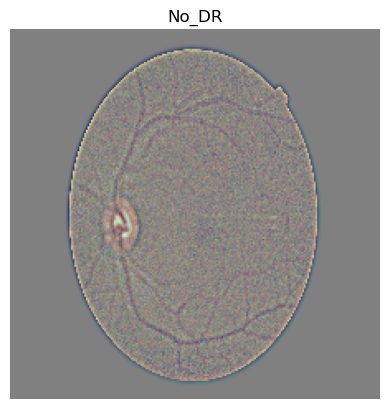

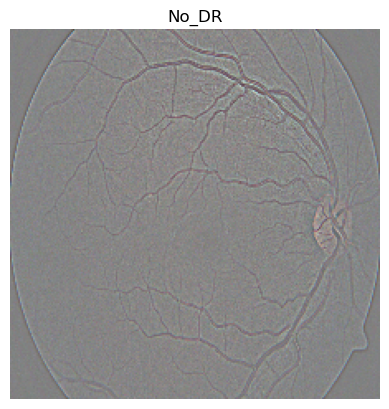

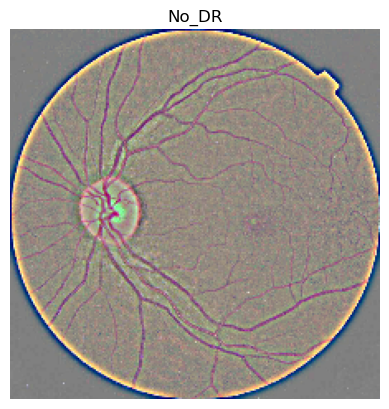

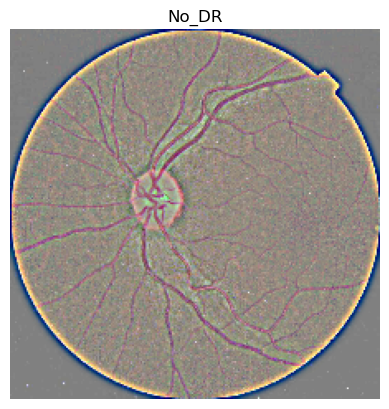

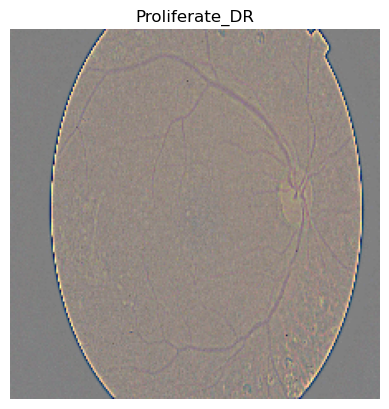

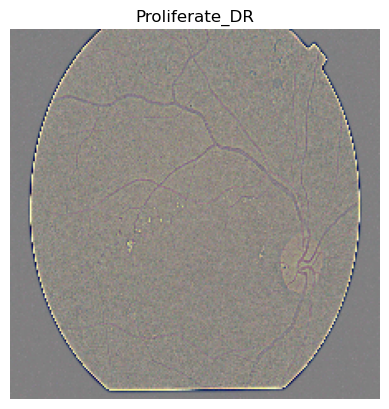

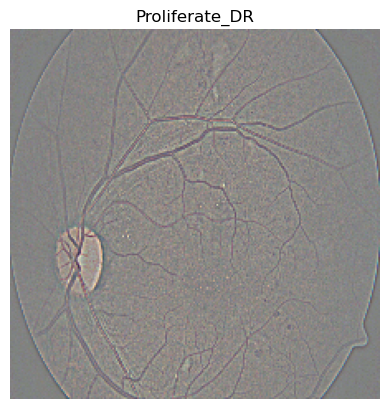

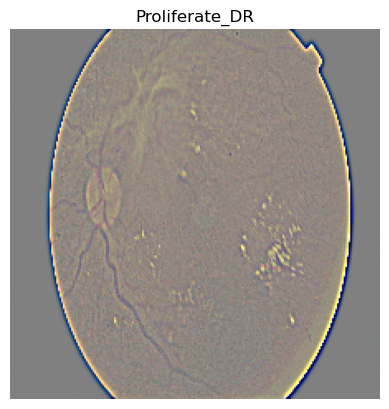

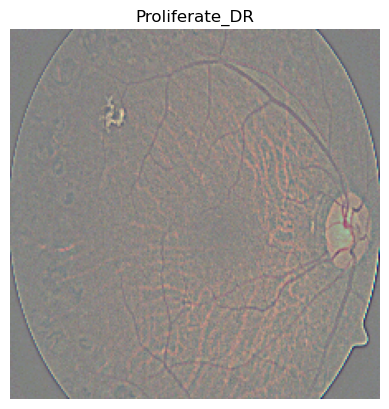

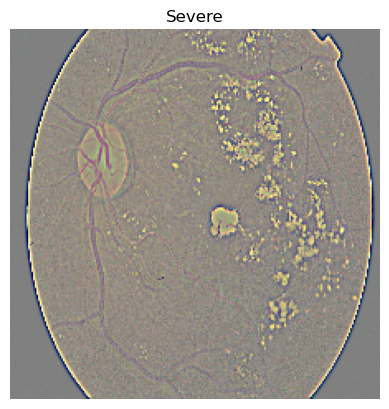

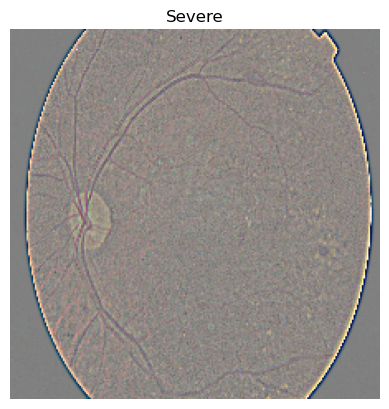

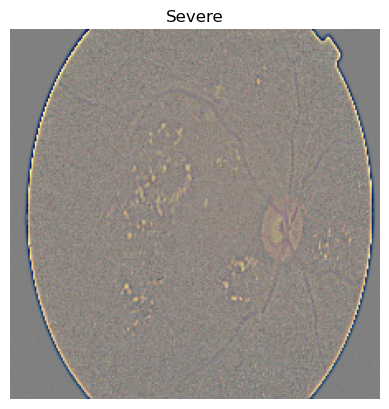

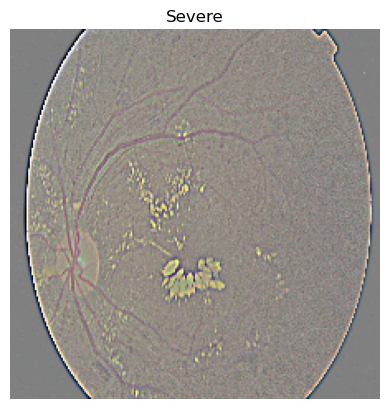

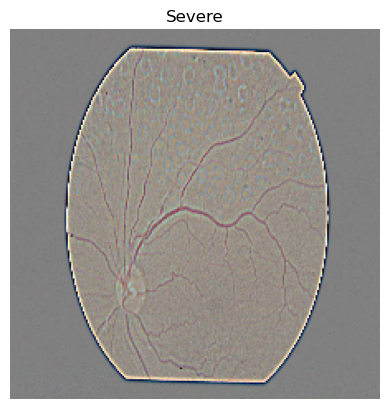

In [13]:
# Function to display images from a subfolder
import matplotlib.pyplot as plt
from PIL import Image
import io

def display_images(subfolder):
    # List objects in the subfolder
    response = s3_client.list_objects_v2(Bucket=bucket, Prefix=f'{train_prefix}{subfolder}/')
    objects = response.get('Contents', [])
    
    # Display the first few images
    num_images_to_display = 5
    for i in range(min(num_images_to_display, len(objects))):
        object_key = objects[i]['Key']
        image_data = s3_client.get_object(Bucket=bucket, Key=object_key)['Body'].read()
        image = Image.open(io.BytesIO(image_data))
        # Convert the image tensor to a numpy array (if needed)
        image_np = image.squeeze().numpy()
        plt.figure()
        plt.imshow(image_np)
        plt.title(subfolder)
        plt.axis('off')

# Display images from each subfolder
for subfolder in subfolders:
    display_images(subfolder)

plt.show()